# Assignment 7

Welcome to the assignment for week 7.

## Task 7: Backpropagation

Read the Rojas book (https://www.inf.fu-berlin.de/inst/ag-ki/rojas_home/documents/1996/NeuralNetworks/neuron.pdf), chapter 7.3.3 and learn about the "matrix way" of implementing backprop.

### Ex. 7.1 XOR

* Implement a two-layer artificial neural network with two input neurons and one output neuron. Choose the number of hidden neurons to your liking and add an error "neuron" to your network. 
* Our goal is to learn the XOR function. What does the network return for random weights of all combinations of (binary) inputs? **(RESULT)**

In [51]:

import numpy as np

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  
y = np.array([[0], [1], [1], [0]])  


np.random.seed(42)
input_neurons = 2  
hidden_neurons = 4  
output_neurons = 1  

# Random weights and biases
W1 = np.random.randn(input_neurons, hidden_neurons) 
b1 = np.random.randn(1, hidden_neurons)  
W2 = np.random.randn(hidden_neurons, output_neurons)  
b2 = np.random.randn(1, output_neurons) 


def sigmoid(x):
    return 1 / (1 + np.exp(-x))  

def forward_pass(X):
  
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)  
    
    
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)  
    return a2


outputs = forward_pass(X)


for i in range(len(X)):
    print(f"Input: {X[i]}, Predicted: {outputs[i][0]:.4f}, Target: {y[i][0]}")


error = np.mean((outputs - y) ** 2)
print(f"\nInitial Error (Mean Squared Error): {error:.4f}")

Input: [0 0], Predicted: 0.0469, Target: 0
Input: [0 1], Predicted: 0.0251, Target: 1
Input: [1 0], Predicted: 0.0324, Target: 1
Input: [1 1], Predicted: 0.0199, Target: 0

Initial Error (Mean Squared Error): 0.4723


### Task 7.2: Backpropagation

Implement Backpropagation and optimize the weights of your neural network using the XOR training set: 

| x | y |
| -------- | ------- |
| (0,0) | 0 |
| (0,1) | 1 |
| (1,0) | 1 |
| (1,1) | 0 |

* How many training iterations do you need? Plot the network error over the number of iterations! **(RESULT)**

In [52]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = np.array([[0,0], [0,1], [1,0] , [1,1]])
y = np.array([[0], [1], [1], [0]])

model = Sequential([
    Dense(4, input_dim = 2, activation = 'tanh'),
    Dense(1, activation = 'sigmoid')
])

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.losses = []  # List to store loss values at each epoch

    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs['loss'])  # Append the loss value

# Instantiate the callback
loss_history = LossHistory()

history = model.fit(X, y, epochs = 2000, verbose = 0, callbacks=[loss_history])

predection = model.predict(X)


C:\Users\Massi\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


[[0.03102733]
 [0.85076565]
 [0.95607764]
 [0.17833395]]


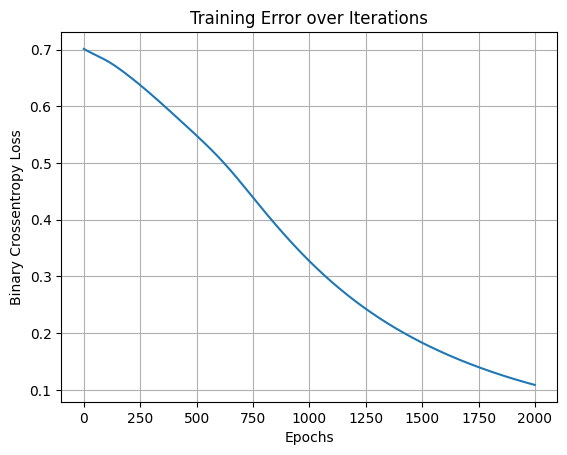

In [53]:
import matplotlib.pyplot as plt
print(predection)
print(history)
plt.plot(loss_history.losses)
plt.title("Training Error over Iterations")
plt.xlabel("Epochs")
plt.ylabel("Binary Crossentropy Loss")
plt.grid()
plt.show()

### Task 7.3: MNIST (BONUS)

* Train your network on the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) and state the model accuracy (or the model error) for the training and test sets. **(RESULT)** 
* Compare to this [list](https://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html#4d4e495354) and report on the performance of your model. **(RESULT)**

In [54]:
# You can access MNIST using torchvision (https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html)

import torch
from torchvision import datasets, transforms


transform = transforms.Compose([
    transforms.ToTensor(),                #scaling to [0,1]
    transforms.Normalize((0.5,), (0.5))   #normalize [-1,1]
])

train_dataset = datasets.MNIST(
    root="./data",       # Directory to store the dataset
    train=True,          # Load the training set
    transform=transform, # Apply transformations
    download=True        # Download if not already available
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,         # Load the test set
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

In [55]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

for images, labels in train_loader:
    x_train = images  # Images (features)
    y_train = labels  # Labels (targets)
    break

for images, labels in test_loader:
    x_test = images
    y_test = labels

model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # Flatten 28x28 images to a 1D vector
    Dense(128, activation='relu'), # First hidden layer with 128 neurons
    Dense(10, activation='softmax') # Output layer with 10 neurons for classification
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=32, verbose=1)

train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1229 - loss: 2.8129  
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3438 - loss: 1.9953 
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6531 - loss: 1.3198 
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7677 - loss: 1.0182 
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7979 - loss: 0.8568 


In [56]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
#Performance the best Method has an error margin of 0.21% which is more than 50 times better then this model (12.5% error margin) 
#Compared to the worst Method in List its supreseling better (14.53 % error margin)  

Training Accuracy: 0.8750
Test Accuracy: 0.5000


## Congratz, you made it! :)